In [2]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ---------------- CONFIG ----------------
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Change this path to your FER2013 dataset folder
DATASET_PATH = "/kaggle/input/fer2013"

# Models will be saved here
SAVE_DIR = "/kaggle/working/fer2013_models"
os.makedirs(SAVE_DIR, exist_ok=True)

Device: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [6]:
import os

DATASET_PATH = "/kaggle/input/datasets/msambare/fer2013"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 3:
        dirs[:] = []

fer2013/
    test/
        surprise/
        fear/
        angry/
        neutral/
        sad/
        disgust/
        happy/
    train/
        surprise/
        fear/
        angry/
        neutral/
        sad/
        disgust/
        happy/


In [8]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def collect_images(dataset_path):
    image_paths = []
    labels = []

    # Handles FER2013/train/class_name/image.jpg
    # Also handles FER2013/class_name/image.jpg
    for root, _, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(IMAGE_EXTENSIONS):
                full_path = os.path.join(root, file)

                # Class label is parent folder name
                label_name = os.path.basename(os.path.dirname(full_path))

                # Ignore generic train/test folder labels if needed
                if label_name.lower() in ["train", "test", "validation", "val"]:
                    continue

                image_paths.append(full_path)
                labels.append(label_name)

    return image_paths, labels

all_paths, all_labels = collect_images(DATASET_PATH)

print("Total images found:", len(all_paths))
print("Unique classes:", sorted(set(all_labels)))

label_counts = pd.Series(all_labels).value_counts().sort_index()
print("\nImages per class:")
print(label_counts)

Total images found: 35887
Unique classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Images per class:
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64


In [9]:
class_names = sorted(list(set(all_labels)))
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

encoded_labels = [class_to_idx[label] for label in all_labels]

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths,
    encoded_labels,
    test_size=0.40,          # 40% test
    random_state=SEED,
    stratify=encoded_labels  # keeps each emotion balanced
)

print("Classes:", class_names)
print("Number of classes:", len(class_names))
print("Train images (60%):", len(train_paths))
print("Test images (40%):", len(test_paths))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Train images (60%): 21532
Test images (40%): 14355


In [10]:
train_distribution = pd.Series(train_labels).map(idx_to_class).value_counts().sort_index()
test_distribution = pd.Series(test_labels).map(idx_to_class).value_counts().sort_index()

split_df = pd.DataFrame({
    "Train (60%)": train_distribution,
    "Test (40%)": test_distribution
})

print(split_df)

          Train (60%)  Test (40%)
angry            2972        1981
disgust           328         219
fear             3073        2048
happy            5393        3596
neutral          3719        2479
sad              3646        2431
surprise         2401        1601


In [12]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
class FERDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [23]:
# CELL 9 — Safe DataLoaders for Kaggle

from torch.utils.data import DataLoader

NUM_WORKERS = 0
PIN_MEMORY = False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train images: 21532
Test images: 14355
Train batches: 673
Test batches: 449


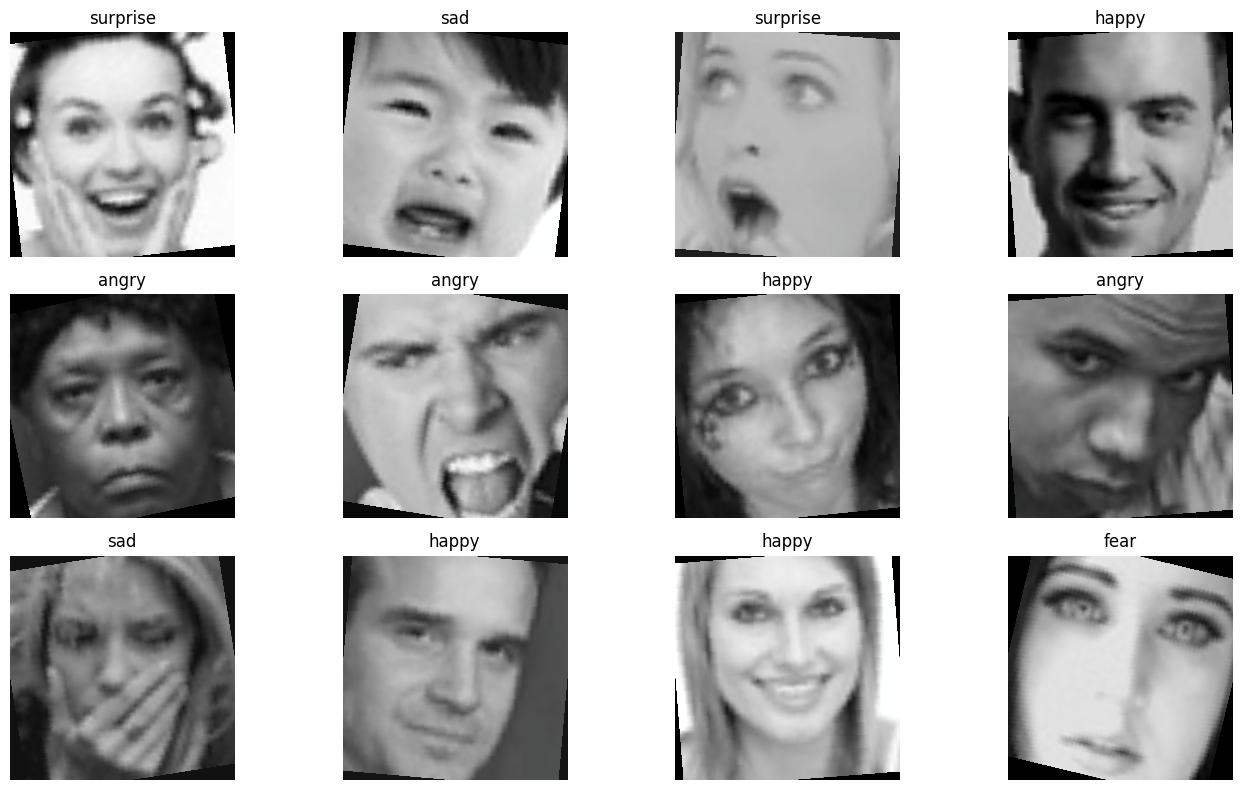

In [15]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    image = images[i].permute(1, 2, 0).numpy()
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.title(idx_to_class[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
def create_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    # Train final ResNet layer
    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )

    return model

In [37]:
# CELL 13 — Define EfficientNet-B0 model

import torch.nn as nn
from torchvision import models

def create_efficientnet_b0(num_classes=7, pretrained=True):

    if pretrained:
        weights = models.EfficientNet_B0_Weights.DEFAULT
    else:
        weights = None

    model = models.efficientnet_b0(weights=weights)

    # Freeze pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Train last feature block
    for param in model.features[-1].parameters():
        param.requires_grad = True

    # Replace final classifier for FER2013
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )

    return model

print("EfficientNet-B0 function created successfully.")

EfficientNet-B0 function created successfully.


In [20]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_predictions), np.array(all_labels)

In [32]:
# CELL 15 — Training function with batch progress bar

import copy
import torch
import torch.nn as nn
from tqdm.auto import tqdm

def train_model(model, model_name, epochs=30):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4,
        weight_decay=1e-4
    )

    best_accuracy = 0.0
    best_epoch = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    print(f"\n{'='*60}")
    print(f"Training Started: {model_name}")
    print(f"Total Epochs: {epochs}")
    print(f"{'='*60}\n")

    for epoch in range(1, epochs + 1):

        # ---------------- TRAIN ----------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs} - Training",
            leave=True
        )

        for images, labels in train_bar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            current_accuracy = 100 * correct / total

            train_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                accuracy=f"{current_accuracy:.2f}%"
            )

        train_loss = running_loss / total
        train_accuracy = correct / total

        # ---------------- TEST ----------------
        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        test_bar = tqdm(
            test_loader,
            desc=f"Epoch {epoch}/{epochs} - Testing",
            leave=True
        )

        with torch.no_grad():
            for images, labels in test_bar:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * images.size(0)

                predictions = torch.argmax(outputs, dim=1)
                test_correct += (predictions == labels).sum().item()
                test_total += labels.size(0)

                current_test_accuracy = 100 * test_correct / test_total

                test_bar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    accuracy=f"{current_test_accuracy:.2f}%"
                )

        test_loss = test_running_loss / test_total
        test_accuracy = test_correct / test_total

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        print(
            f"\nEpoch [{epoch}/{epochs}] Finished | "
            f"Train Acc: {train_accuracy * 100:.2f}% | "
            f"Test Acc: {test_accuracy * 100:.2f}%"
        )

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch
            best_model_weights = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "model_name": model_name,
                    "epoch": epoch,
                    "model_state_dict": best_model_weights,
                    "test_accuracy": best_accuracy,
                    "class_names": class_names,
                    "class_to_idx": class_to_idx,
                    "img_size": IMG_SIZE
                },
                f"/kaggle/working/{model_name}_best.pth"
            )

            print(
                f"✓ Best model saved at Epoch {epoch} | "
                f"Test Accuracy: {best_accuracy * 100:.2f}%"
            )

    model.load_state_dict(best_model_weights)

    print(f"\n{'='*60}")
    print(f"{model_name} Training Finished")
    print(f"Total Epochs Trained: {epochs}")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Test Accuracy: {best_accuracy * 100:.2f}%")
    print(f"{'='*60}\n")

    return model, history, best_accuracy, best_epoch

In [33]:
# CELL 16 — Train CustomCNN

customcnn_model = CustomCNN(num_classes=len(class_names))

customcnn_model, customcnn_history, customcnn_best_acc, customcnn_best_epoch = train_model(
    model=customcnn_model,
    model_name="CustomCNN",
    epochs=30
)


Training Started: CustomCNN
Total Epochs: 30



Epoch 1/30 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 1/30 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [1/30] Finished | Train Acc: 25.18% | Test Acc: 29.68%
✓ Best model saved at Epoch 1 | Test Accuracy: 29.68%


Epoch 2/30 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

...

Epoch 29/30 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [29/30] Finished | Train Acc: 54.72% | Test Acc: 41.19%


Epoch 30/30 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 30/30 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [30/30] Finished | Train Acc: 55.28% | Test Acc: 47.98%

CustomCNN Training Finished
Total Epochs Trained: 30
Best Epoch: 26
Best Test Accuracy: 55.71%



In [34]:
# CELL 17 — Train ResNet50

resnet50_model = create_resnet50(num_classes=len(class_names))

resnet50_model, resnet50_history, resnet50_best_acc, resnet50_best_epoch = train_model(
    model=resnet50_model,
    model_name="ResNet50",
    epochs=15
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 



Training Started: ResNet50
Total Epochs: 15



Epoch 1/15 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 1/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]

...

Epoch 14/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [14/15] Finished | Train Acc: 78.13% | Test Acc: 63.09%


Epoch 15/15 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 15/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [15/15] Finished | Train Acc: 79.39% | Test Acc: 62.93%

ResNet50 Training Finished
Total Epochs Trained: 15
Best Epoch: 12
Best Test Accuracy: 63.85%



In [39]:
# CELL 18 — Train EfficientNet-B0

efficientnet_model = create_efficientnet_b0(
    num_classes=len(class_names),
    pretrained=True
)

efficientnet_model, efficientnet_history, efficientnet_best_acc, efficientnet_best_epoch = train_model(
    model=efficientnet_model,
    model_name="EfficientNetB0",
    epochs=15
)


Training Started: EfficientNetB0
Total Epochs: 15



Epoch 1/15 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 1/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [1/15] Finished | Train Acc: 32.00% | Test Acc: 37.88%
✓ Best model saved at Epoch 1 | Test Accuracy: 37.88%


Epoch 2/15 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

...

Epoch 14/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [14/15] Finished | Train Acc: 48.56% | Test Acc: 49.25%


Epoch 15/15 - Training:   0%|          | 0/673 [00:00<?, ?it/s]

Epoch 15/15 - Testing:   0%|          | 0/449 [00:00<?, ?it/s]


Epoch [15/15] Finished | Train Acc: 49.33% | Test Acc: 49.89%
✓ Best model saved at Epoch 15 | Test Accuracy: 49.89%

EfficientNetB0 Training Finished
Total Epochs Trained: 15
Best Epoch: 15
Best Test Accuracy: 49.89%



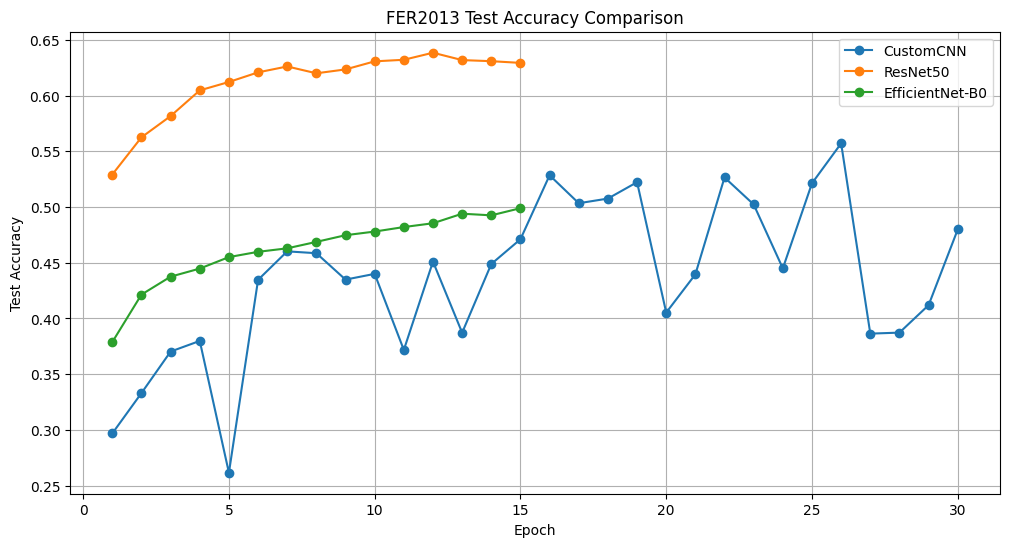

Graph saved: /kaggle/working/fer2013_model_test_accuracy.png


In [41]:
# CELL 19 — Plot test accuracy of all models

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    customcnn_history["epoch"],
    customcnn_history["test_accuracy"],
    marker="o",
    label="CustomCNN"
)

plt.plot(
    resnet50_history["epoch"],
    resnet50_history["test_accuracy"],
    marker="o",
    label="ResNet50"
)

plt.plot(
    efficientnet_history["epoch"],
    efficientnet_history["test_accuracy"],
    marker="o",
    label="EfficientNet-B0"
)

plt.title("FER2013 Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "/kaggle/working/fer2013_model_test_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved: /kaggle/working/fer2013_model_test_accuracy.png")

In [42]:
# CELL 20 — Get probabilities from all trained models

import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def get_probabilities(model, loader):
    model.eval()

    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Getting probabilities"):
            images = images.to(DEVICE)

            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)

            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.vstack(all_probabilities), np.concatenate(all_labels)


customcnn_probs, true_labels = get_probabilities(customcnn_model, test_loader)
resnet50_probs, _ = get_probabilities(resnet50_model, test_loader)
efficientnet_probs, _ = get_probabilities(efficientnet_model, test_loader)

print("CustomCNN:", customcnn_probs.shape)
print("ResNet50:", resnet50_probs.shape)
print("EfficientNet-B0:", efficientnet_probs.shape)

Getting probabilities:   0%|          | 0/449 [00:00<?, ?it/s]

Getting probabilities:   0%|          | 0/449 [00:00<?, ?it/s]

Getting probabilities:   0%|          | 0/449 [00:00<?, ?it/s]

CustomCNN: (14355, 7)
ResNet50: (14355, 7)
EfficientNet-B0: (14355, 7)


In [43]:
# CELL 21 — Simple DST fusion for two models

def probability_to_mass(probabilities):
    """
    Converts one model's softmax output into DST class masses.
    """
    return {
        class_index: float(probability)
        for class_index, probability in enumerate(probabilities)
    }


def dempster_combine(mass_1, mass_2, num_classes):
    """
    Basic Dempster's rule for singleton emotion classes.
    """
    combined_mass = {class_index: 0.0 for class_index in range(num_classes)}
    conflict = 0.0

    for class_1, value_1 in mass_1.items():
        for class_2, value_2 in mass_2.items():

            if class_1 == class_2:
                combined_mass[class_1] += value_1 * value_2
            else:
                conflict += value_1 * value_2

    denominator = 1.0 - conflict

    # Safety fallback when there is very high conflict
    if denominator <= 1e-12:
        fused_scores = np.array([
            combined_mass[class_index]
            for class_index in range(num_classes)
        ])

        if fused_scores.sum() == 0:
            fused_scores = np.ones(num_classes) / num_classes
        else:
            fused_scores = fused_scores / fused_scores.sum()

        return fused_scores

    for class_index in combined_mass:
        combined_mass[class_index] /= denominator

    fused_scores = np.array([
        combined_mass[class_index]
        for class_index in range(num_classes)
    ])

    return fused_scores


def simple_dst_two_models(model_1_probabilities, model_2_probabilities):
    """
    Apply Simple DST between exactly two models.
    """

    num_classes = len(model_1_probabilities)

    mass_1 = probability_to_mass(model_1_probabilities)
    mass_2 = probability_to_mass(model_2_probabilities)

    fused_scores = dempster_combine(
        mass_1,
        mass_2,
        num_classes
    )

    final_prediction = np.argmax(fused_scores)

    return final_prediction, fused_scores

In [44]:
# CELL 22 — Simple DST: CustomCNN + ResNet50

customcnn_resnet_dst_predictions = []
customcnn_resnet_dst_confidence = []

for i in tqdm(range(len(true_labels)), desc="DST: CustomCNN + ResNet50"):

    prediction, fused_scores = simple_dst_two_models(
        customcnn_probs[i],
        resnet50_probs[i]
    )

    customcnn_resnet_dst_predictions.append(prediction)
    customcnn_resnet_dst_confidence.append(np.max(fused_scores))

customcnn_resnet_dst_predictions = np.array(customcnn_resnet_dst_predictions)
customcnn_resnet_dst_confidence = np.array(customcnn_resnet_dst_confidence)

print("CustomCNN + ResNet50 DST completed.")

DST: CustomCNN + ResNet50:   0%|          | 0/14355 [00:00<?, ?it/s]

CustomCNN + ResNet50 DST completed.


In [45]:
# CELL 23 — Simple DST: CustomCNN + EfficientNet-B0

customcnn_efficientnet_dst_predictions = []
customcnn_efficientnet_dst_confidence = []

for i in tqdm(range(len(true_labels)), desc="DST: CustomCNN + EfficientNet-B0"):

    prediction, fused_scores = simple_dst_two_models(
        customcnn_probs[i],
        efficientnet_probs[i]
    )

    customcnn_efficientnet_dst_predictions.append(prediction)
    customcnn_efficientnet_dst_confidence.append(np.max(fused_scores))

customcnn_efficientnet_dst_predictions = np.array(customcnn_efficientnet_dst_predictions)
customcnn_efficientnet_dst_confidence = np.array(customcnn_efficientnet_dst_confidence)

print("CustomCNN + EfficientNet-B0 DST completed.")

DST: CustomCNN + EfficientNet-B0:   0%|          | 0/14355 [00:00<?, ?it/s]

CustomCNN + EfficientNet-B0 DST completed.


In [46]:
# CELL 24 — Simple DST: ResNet50 + EfficientNet-B0

resnet_efficientnet_dst_predictions = []
resnet_efficientnet_dst_confidence = []

for i in tqdm(range(len(true_labels)), desc="DST: ResNet50 + EfficientNet-B0"):

    prediction, fused_scores = simple_dst_two_models(
        resnet50_probs[i],
        efficientnet_probs[i]
    )

    resnet_efficientnet_dst_predictions.append(prediction)
    resnet_efficientnet_dst_confidence.append(np.max(fused_scores))

resnet_efficientnet_dst_predictions = np.array(resnet_efficientnet_dst_predictions)
resnet_efficientnet_dst_confidence = np.array(resnet_efficientnet_dst_confidence)

print("ResNet50 + EfficientNet-B0 DST completed.")

DST: ResNet50 + EfficientNet-B0:   0%|          | 0/14355 [00:00<?, ?it/s]

ResNet50 + EfficientNet-B0 DST completed.


In [53]:
# CELL 25 — Simple DST: CustomCNN + ResNet50 + EfficientNet-B0

def simple_dst_three_models(prob_1, prob_2, prob_3):
    """
    Applies Simple DST fusion sequentially:
    (CustomCNN ⊕ ResNet50) ⊕ EfficientNet-B0
    """

    num_classes = len(prob_1)

    mass_1 = probability_to_mass(prob_1)
    mass_2 = probability_to_mass(prob_2)
    mass_3 = probability_to_mass(prob_3)

    # First fusion: CustomCNN + ResNet50
    fused_mass_12 = dempster_combine(
        mass_1,
        mass_2,
        num_classes
    )

    # Convert fused scores back to mass dictionary
    fused_mass_12_dict = {
        class_index: float(fused_mass_12[class_index])
        for class_index in range(num_classes)
    }

    # Final fusion: (CustomCNN + ResNet50) + EfficientNet-B0
    final_fused_scores = dempster_combine(
        fused_mass_12_dict,
        mass_3,
        num_classes
    )

    final_prediction = np.argmax(final_fused_scores)

    return final_prediction, final_fused_scores

In [54]:
# CELL 26 — Apply Simple DST fusion for all 3 models

three_model_dst_predictions = []
three_model_dst_confidences = []

for i in tqdm(
    range(len(true_labels)),
    desc="DST: CustomCNN + ResNet50 + EfficientNet-B0"
):
    prediction, fused_scores = simple_dst_three_models(
        customcnn_probs[i],
        resnet50_probs[i],
        efficientnet_probs[i]
    )

    three_model_dst_predictions.append(prediction)
    three_model_dst_confidences.append(np.max(fused_scores))

three_model_dst_predictions = np.array(three_model_dst_predictions)
three_model_dst_confidences = np.array(three_model_dst_confidences)

print("Three-model Simple DST fusion completed.")

DST: CustomCNN + ResNet50 + EfficientNet-B0:   0%|          | 0/14355 [00:00<?, ?it/s]

Three-model Simple DST fusion completed.


In [55]:
# CELL 27 — Three-model DST accuracy

three_model_dst_accuracy = accuracy_score(
    true_labels,
    three_model_dst_predictions
)

print(
    f"CustomCNN + ResNet50 + EfficientNet-B0 "
    f"Simple DST Accuracy: {three_model_dst_accuracy * 100:.2f}%"
)

CustomCNN + ResNet50 + EfficientNet-B0 Simple DST Accuracy: 64.94%


,Model / Combination,Test Accuracy (%)
0,CustomCNN + ResNet50 (Normal DST),65.41
1,CustomCNN + ResNet50 + EfficientNet-B0 (Normal...,64.94
2,ResNet50 + EfficientNet-B0 (Normal DST),64.31
3,ResNet50,63.85
4,CustomCNN + EfficientNet-B0 (Normal DST),57.08
5,Custom CNN,55.71
6,EfficientNet-B0,49.89


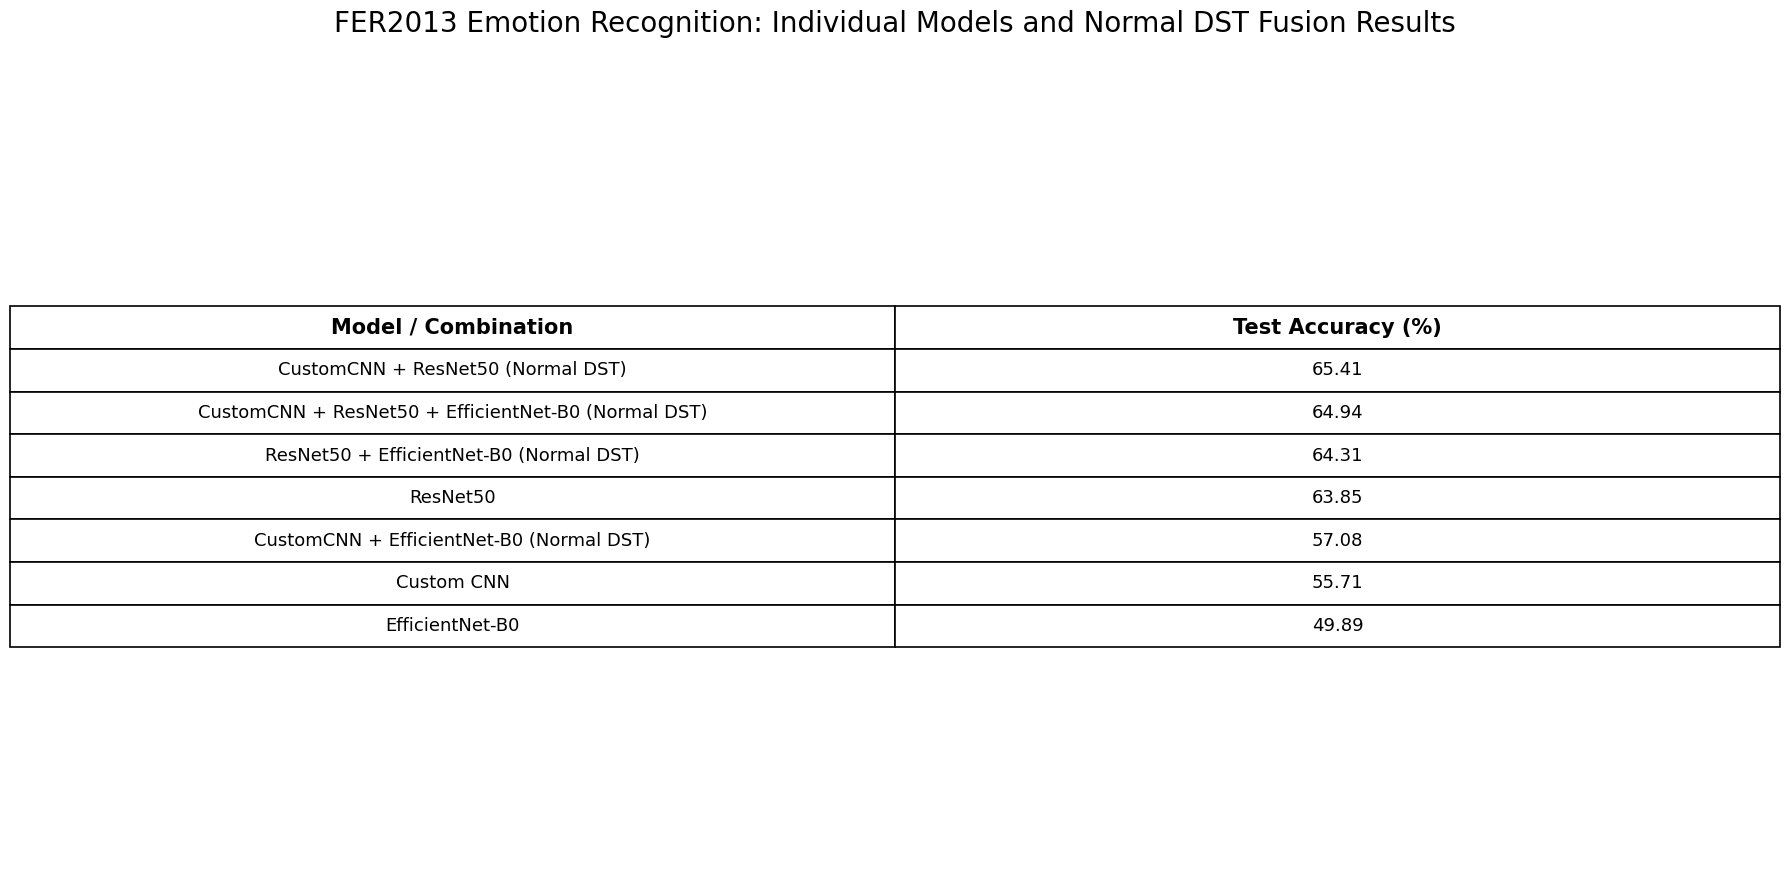

Saved PNG: /kaggle/working/fer2013_normal_dst_results_table.png


In [56]:
# CELL 33 — Create accuracy table + Normal DST result PNG

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Create predictions for individual models
customcnn_predictions = np.argmax(customcnn_probs, axis=1)
resnet50_predictions = np.argmax(resnet50_probs, axis=1)
efficientnet_predictions = np.argmax(efficientnet_probs, axis=1)

# Create full accuracy table
accuracy_table = pd.DataFrame({
    "Model / Combination": [
        "Custom CNN",
        "ResNet50",
        "EfficientNet-B0",
        "CustomCNN + ResNet50 (Normal DST)",
        "CustomCNN + EfficientNet-B0 (Normal DST)",
        "ResNet50 + EfficientNet-B0 (Normal DST)",
        "CustomCNN + ResNet50 + EfficientNet-B0 (Normal DST)"
    ],
    "Test Accuracy (%)": [
        accuracy_score(true_labels, customcnn_predictions) * 100,
        accuracy_score(true_labels, resnet50_predictions) * 100,
        accuracy_score(true_labels, efficientnet_predictions) * 100,
        accuracy_score(true_labels, customcnn_resnet_dst_predictions) * 100,
        accuracy_score(true_labels, customcnn_efficientnet_dst_predictions) * 100,
        accuracy_score(true_labels, resnet_efficientnet_dst_predictions) * 100,
        accuracy_score(true_labels, three_model_dst_predictions) * 100
    ]
})

# Round and sort
accuracy_table["Test Accuracy (%)"] = accuracy_table["Test Accuracy (%)"].round(2)

accuracy_table = accuracy_table.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

# Show normal dataframe table first
display(accuracy_table)

# Create PNG table
fig, ax = plt.subplots(figsize=(18, 9))
ax.axis("off")

table = ax.table(
    cellText=accuracy_table.values,
    colLabels=accuracy_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2.2)

# Format header and borders
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(1.2)

    if row == 0:
        cell.set_text_props(weight="bold", fontsize=15)
    else:
        cell.set_text_props(fontsize=13)

plt.title(
    "FER2013 Emotion Recognition: Individual Models and Normal DST Fusion Results",
    fontsize=20,
    pad=30
)

plt.tight_layout()

output_path = "/kaggle/working/fer2013_normal_dst_results_table.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved PNG:", output_path)

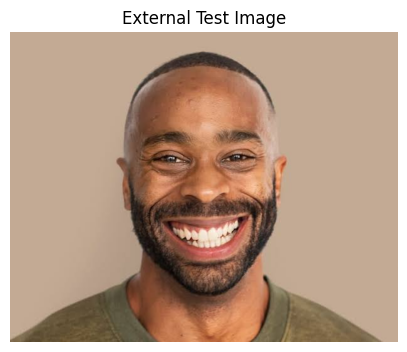

Image loaded successfully.


In [57]:
# CELL 34 — Load and prepare an external image

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Change this to your uploaded image path
IMAGE_PATH = "/kaggle/input/datasets/cbinayak70/my-datas/happy.jpeg"

# Same transform used during testing
external_image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(IMAGE_PATH).convert("RGB")

image_tensor = external_image_transform(image)
image_batch = image_tensor.unsqueeze(0).to(DEVICE)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("External Test Image")
plt.axis("off")
plt.show()

print("Image loaded successfully.")

In [59]:
# CELL 36 — DST fusion prediction for external image

# CustomCNN + ResNet50
cnn_resnet_pred, cnn_resnet_scores = simple_dst_two_models(
    customcnn_external_probs,
    resnet50_external_probs
)

# CustomCNN + EfficientNet-B0
cnn_efficientnet_pred, cnn_efficientnet_scores = simple_dst_two_models(
    customcnn_external_probs,
    efficientnet_external_probs
)

# ResNet50 + EfficientNet-B0
resnet_efficientnet_pred, resnet_efficientnet_scores = simple_dst_two_models(
    resnet50_external_probs,
    efficientnet_external_probs
)

# All 3 models
three_model_pred, three_model_scores = simple_dst_three_models(
    customcnn_external_probs,
    resnet50_external_probs,
    efficientnet_external_probs
)

print("\n" + "=" * 70)
print("EXTERNAL IMAGE EMOTION PREDICTION RESULTS")
print("=" * 70)

print(f"CustomCNN                              : {idx_to_class[customcnn_pred_idx]} ({customcnn_conf:.2f}%)")
print(f"ResNet50                               : {idx_to_class[resnet50_pred_idx]} ({resnet50_conf:.2f}%)")
print(f"EfficientNet-B0                        : {idx_to_class[efficientnet_pred_idx]} ({efficientnet_conf:.2f}%)")

print("-" * 70)

print(f"CustomCNN + ResNet50 DST               : {idx_to_class[cnn_resnet_pred]} ({np.max(cnn_resnet_scores) * 100:.2f}%)")
print(f"CustomCNN + EfficientNet-B0 DST        : {idx_to_class[cnn_efficientnet_pred]} ({np.max(cnn_efficientnet_scores) * 100:.2f}%)")
print(f"ResNet50 + EfficientNet-B0 DST         : {idx_to_class[resnet_efficientnet_pred]} ({np.max(resnet_efficientnet_scores) * 100:.2f}%)")

print("-" * 70)

print(f"All 3 Models Combined DST              : {idx_to_class[three_model_pred]} ({np.max(three_model_scores) * 100:.2f}%)")

print("=" * 70)


EXTERNAL IMAGE EMOTION PREDICTION RESULTS
CustomCNN                              : neutral (32.66%)
ResNet50                               : sad (99.99%)
EfficientNet-B0                        : happy (34.80%)
----------------------------------------------------------------------
CustomCNN + ResNet50 DST               : sad (100.00%)
CustomCNN + EfficientNet-B0 DST        : happy (36.88%)
ResNet50 + EfficientNet-B0 DST         : sad (99.99%)
----------------------------------------------------------------------
All 3 Models Combined DST              : sad (100.00%)


In [58]:
# CELL 35 — Individual model predictions

def predict_single_model(model, image_batch):
    model.eval()

    with torch.no_grad():
        outputs = model(image_batch)
        probabilities = F.softmax(outputs, dim=1).cpu().numpy()[0]

    prediction_index = np.argmax(probabilities)
    confidence = probabilities[prediction_index] * 100

    return prediction_index, confidence, probabilities


customcnn_pred_idx, customcnn_conf, customcnn_external_probs = predict_single_model(
    customcnn_model,
    image_batch
)

resnet50_pred_idx, resnet50_conf, resnet50_external_probs = predict_single_model(
    resnet50_model,
    image_batch
)

efficientnet_pred_idx, efficientnet_conf, efficientnet_external_probs = predict_single_model(
    efficientnet_model,
    image_batch
)

print("CustomCNN Prediction:", idx_to_class[customcnn_pred_idx], f"({customcnn_conf:.2f}%)")
print("ResNet50 Prediction:", idx_to_class[resnet50_pred_idx], f"({resnet50_conf:.2f}%)")
print("EfficientNet-B0 Prediction:", idx_to_class[efficientnet_pred_idx], f"({efficientnet_conf:.2f}%)")

CustomCNN Prediction: neutral (32.66%)
ResNet50 Prediction: sad (99.99%)
EfficientNet-B0 Prediction: happy (34.80%)


,Model / Combination,Test Accuracy (%)
0,Custom CNN,55.71
1,ResNet50,63.85
2,EfficientNet-B0,49.89
3,CustomCNN + ResNet50\n(Normal DST),65.41
4,CustomCNN + EfficientNet-B0\n(Normal DST),57.08
5,ResNet50 + EfficientNet-B0\n(Normal DST),64.31
6,All 3 Models\n(Normal DST),64.94


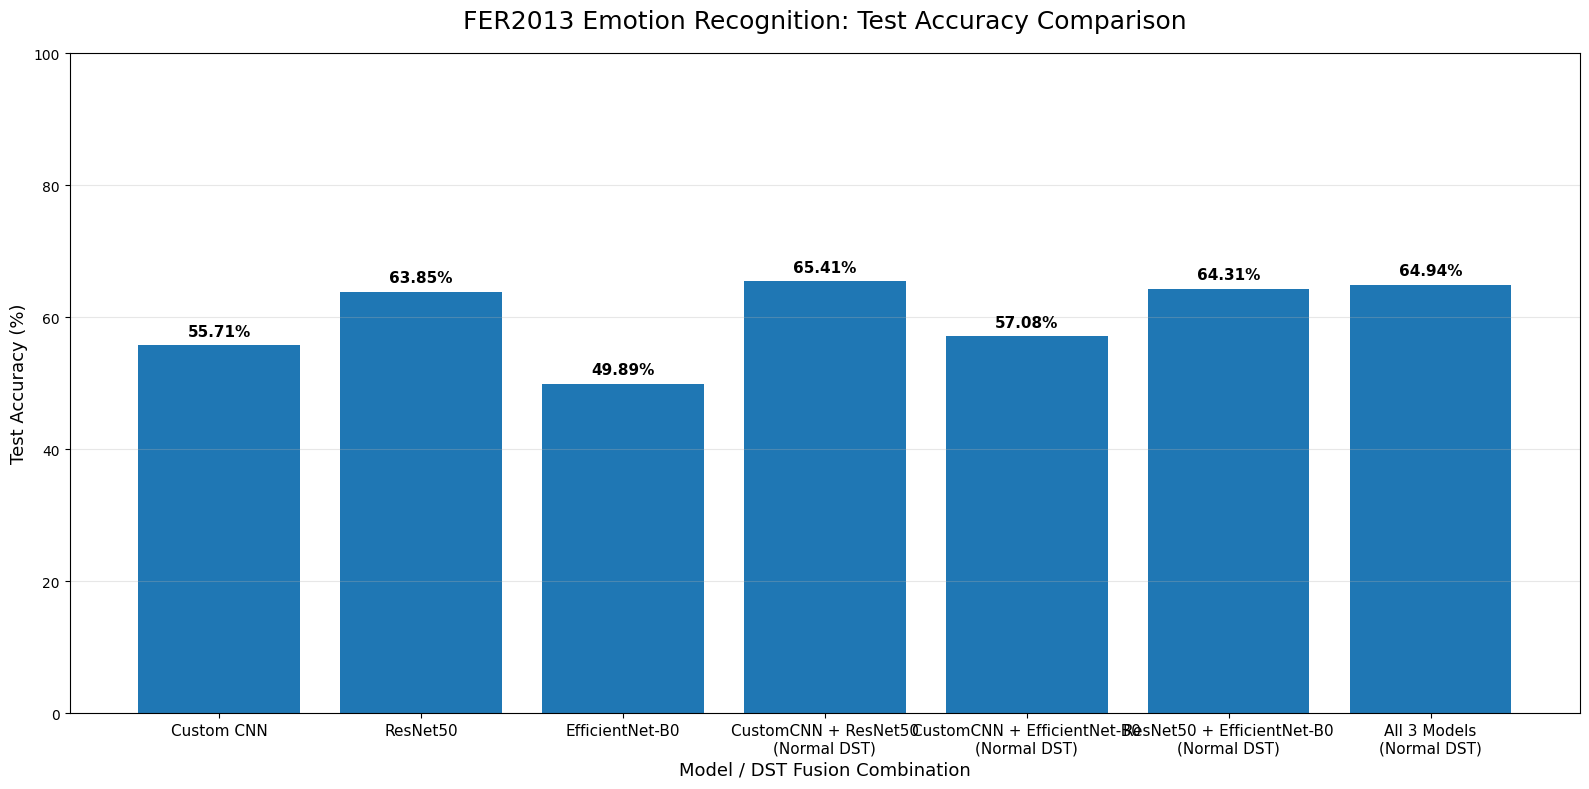

Saved graph: /kaggle/working/fer2013_test_accuracy_comparison_graph.png


In [60]:
# CELL 34 — Test Accuracy Comparison Graph for Models and DST Fusion

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Individual model predictions
customcnn_predictions = np.argmax(customcnn_probs, axis=1)
resnet50_predictions = np.argmax(resnet50_probs, axis=1)
efficientnet_predictions = np.argmax(efficientnet_probs, axis=1)

# Create final validation/test accuracy data
test_accuracy_graph = pd.DataFrame({
    "Model / Combination": [
        "Custom CNN",
        "ResNet50",
        "EfficientNet-B0",
        "CustomCNN + ResNet50\n(Normal DST)",
        "CustomCNN + EfficientNet-B0\n(Normal DST)",
        "ResNet50 + EfficientNet-B0\n(Normal DST)",
        "All 3 Models\n(Normal DST)"
    ],
    "Test Accuracy (%)": [
        accuracy_score(true_labels, customcnn_predictions) * 100,
        accuracy_score(true_labels, resnet50_predictions) * 100,
        accuracy_score(true_labels, efficientnet_predictions) * 100,
        accuracy_score(true_labels, customcnn_resnet_dst_predictions) * 100,
        accuracy_score(true_labels, customcnn_efficientnet_dst_predictions) * 100,
        accuracy_score(true_labels, resnet_efficientnet_dst_predictions) * 100,
        accuracy_score(true_labels, three_model_dst_predictions) * 100
    ]
})

test_accuracy_graph["Test Accuracy (%)"] = test_accuracy_graph["Test Accuracy (%)"].round(2)

display(test_accuracy_graph)

# Create graph
plt.figure(figsize=(16, 8))

bars = plt.bar(
    test_accuracy_graph["Model / Combination"],
    test_accuracy_graph["Test Accuracy (%)"]
)

plt.title(
    "FER2013 Emotion Recognition: Test Accuracy Comparison",
    fontsize=18,
    pad=18
)

plt.xlabel("Model / DST Fusion Combination", fontsize=13)
plt.ylabel("Test Accuracy (%)", fontsize=13)

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0, fontsize=11)

# Show accuracy above every bar
for bar, accuracy in zip(bars, test_accuracy_graph["Test Accuracy (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

output_path = "/kaggle/working/fer2013_test_accuracy_comparison_graph.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved graph:", output_path)

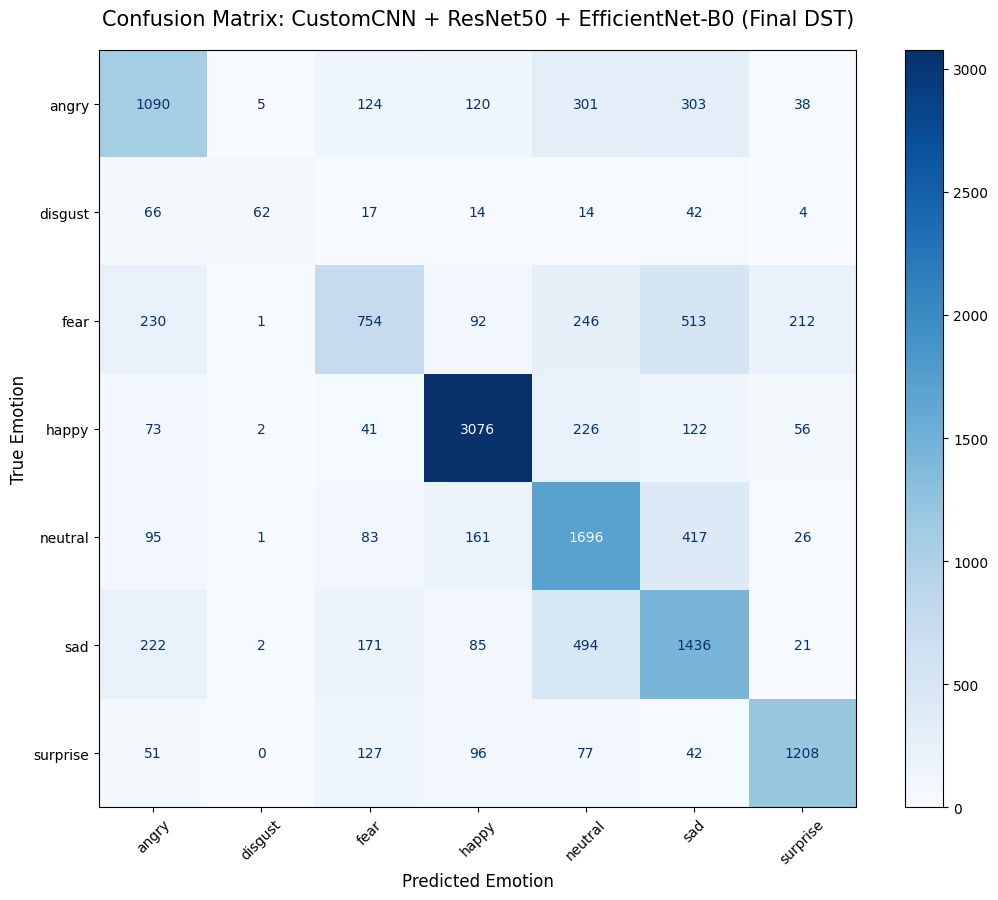

Saved confusion matrix: /kaggle/working/final_three_model_dst_confusion_matrix.png


In [61]:
# CELL 35 — Confusion Matrix for Final 3-Model DST Fusion

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Final DST predictions:
# three_model_dst_predictions
# True test labels:
# true_labels

final_dst_cm = confusion_matrix(
    true_labels,
    three_model_dst_predictions
)

fig, ax = plt.subplots(figsize=(11, 9))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=final_dst_cm,
    display_labels=class_names
)

display_cm.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=True,
    values_format="d"
)

plt.title(
    "Confusion Matrix: CustomCNN + ResNet50 + EfficientNet-B0 (Final DST)",
    fontsize=15,
    pad=18
)

plt.xlabel("Predicted Emotion", fontsize=12)
plt.ylabel("True Emotion", fontsize=12)

plt.tight_layout()

output_path = "/kaggle/working/final_three_model_dst_confusion_matrix.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved confusion matrix:", output_path)